# Support Ticket Data Exploration
In this notebook, I load the dataset, inspect its structure, and explore the main patterns in the support ticket data before building a classification model.

## Load the Data

In [4]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

print("Τα αρχεία φορτώθηκαν σωστά")


Τα αρχεία φορτώθηκαν σωστά


## Check Dataset Size

In [5]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1572, 2)
X_test shape: (657, 2)
y_train shape: (1572, 2)
y_test shape: (657, 2)


## Inspect the Data

In [6]:
X_train.head()

,id,text
0,1919,File Share Access - [TICKET ID] - [NAME]. [NAM...
1,1584,File Share Access - [TICKET ID] - [NAME] ([COM...
2,584,[TICKET ID] - A Support Ticket was forwarded t...
3,1393,[TICKET ID] - A Support Ticket was forwarded t...
4,8636,LVS not respondingLVS will not except my passw...


In [7]:
y_train.head()

,id,category_truth
0,1919,Fileservice
1,1584,Fileservice
2,584,Support general
3,1393,Support general
4,8636,Fileservice


In [8]:
train_df = X_train.merge(y_train, on="id")
test_df = X_test.merge(y_test, on="id")

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

train_df shape: (1572, 3)
test_df shape: (657, 3)


In [9]:
train_df.head()

,id,text,category_truth
0,1919,File Share Access - [TICKET ID] - [NAME]. [NAM...,Fileservice
1,1584,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
2,584,[TICKET ID] - A Support Ticket was forwarded t...,Support general
3,1393,[TICKET ID] - A Support Ticket was forwarded t...,Support general
4,8636,LVS not respondingLVS will not except my passw...,Fileservice


## Check Missing Values

In [10]:
train_df.isnull().sum()

id                0
text              0
category_truth    0
dtype: int64

## Explore Ticket Categories

In [11]:
train_df["category_truth"].value_counts()

category_truth
Fileservice          546
Support general      541
Software             164
O365                 127
Active Directory      84
Computer-Services     65
EOL                   45
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='category_truth'>

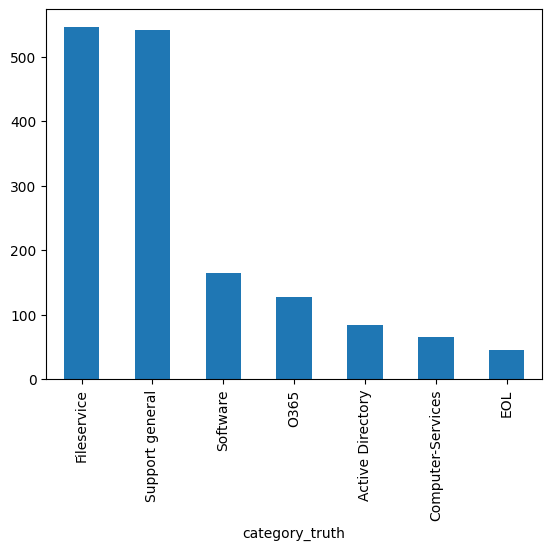

In [12]:
train_df["category_truth"].value_counts().plot(kind="bar")

## Explore Ticket Text Length

In [13]:
train_df["text_length"] = train_df["text"].str.len()
train_df["text_length"].describe()

count    1572.000000
mean      130.627226
std       183.412468
min         8.000000
25%        50.000000
50%        65.000000
75%        92.000000
max      1763.000000
Name: text_length, dtype: float64

<Axes: ylabel='Frequency'>

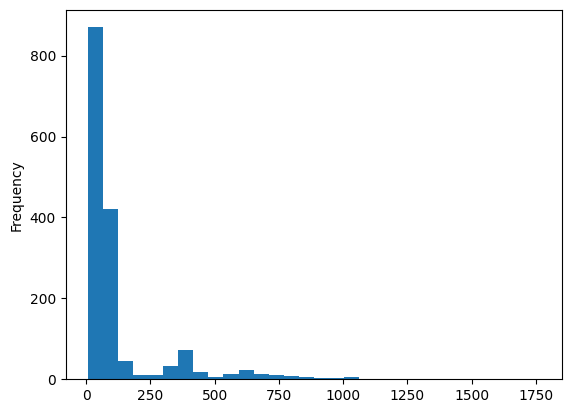

In [14]:
train_df["text_length"].plot(kind="hist", bins=30)

In [15]:
train_df.groupby("category_truth")["text_length"].mean().sort_values(ascending=False)

category_truth
EOL                  407.577778
Support general      153.201479
Fileservice          123.397436
Active Directory     113.428571
O365                  86.023622
Software              75.371951
Computer-Services     60.523077
Name: text_length, dtype: float64

<Axes: ylabel='category_truth'>

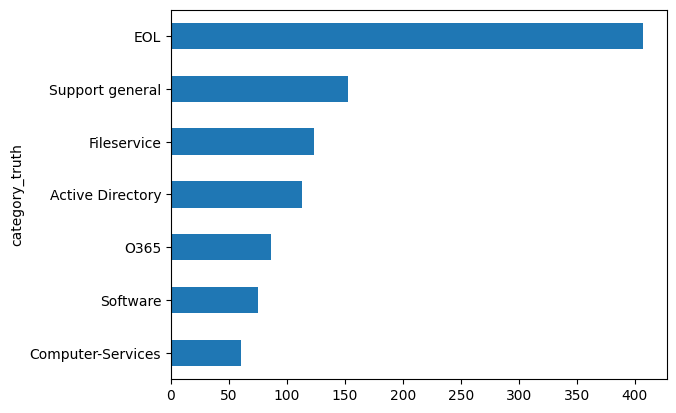

In [16]:
train_df.groupby("category_truth")["text_length"].mean().sort_values().plot(kind="barh")

In [17]:
train_df[["text", "category_truth"]].sample(5, random_state=42)

,text,category_truth
1120,Shared Mailbox Access - [AWS_ACCESS_KEY] - [EM...,Support general
810,[TICKET ID] - A Support Ticket was forwarded t...,Software
1170,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
534,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
514,Local admin rights needed for [SERVER],Active Directory


## Check Repeated Ticket Patterns

In [18]:
train_df["text"].duplicated().sum()

np.int64(610)

In [19]:
train_df[train_df["text"].duplicated(keep=False)][["text", "category_truth"]].head(10)

,text,category_truth
0,File Share Access - [TICKET ID] - [NAME]. [NAM...,Fileservice
1,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
6,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
9,Shared Mailbox Access - [TICKET ID] - [EMAIL],Support general
11,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
12,[TICKET ID] - New Support Ticket received - B...,Support general
15,Remove File Share Access - [TICKET ID] - [NAME...,Fileservice
16,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
17,The following system must be set to End Of Lif...,EOL
18,Shared Mailbox Access - [TICKET ID] - [EMAIL],Support general


In [20]:
train_df["text"].nunique()

962

In [21]:
train_df["category_truth"].value_counts(normalize=True) * 100

category_truth
Fileservice          34.732824
Support general      34.414758
Software             10.432570
O365                  8.078880
Active Directory      5.343511
Computer-Services     4.134860
EOL                   2.862595
Name: proportion, dtype: float64